# Working with A5 in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/03_a5.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/03_a5.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/03_a5.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/03_a5.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [ ]:
# %pip install vgrid --upgrade

### latlon2a5

In [ ]:
from vgrid.conversion.latlon2dggs import latlon2a5
import a5
lat = 10.775276
lon = 106.706797
res = 1
a5_hex = latlon2a5(lat, lon, res)
a5_hex

### A5 to Polygon

In [ ]:
from vgrid.conversion.dggs2geo.a52geo import a52geo
# options = {"segments": 100, "closed_ring": True}
a5_geo = a52geo(a5_hex)
a5_geo

### A5 to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.a52geo import a52geojson
import json
import a5
options = {"segments": 100, "closed_ring": True}
a5_geojson = a52geojson('9b95459d021299d6', options)
# a5_geojson

### Vector to A5

#### (Multi)Point to A5

In [ ]:
from vgrid.conversion.vector2dggs.vector2a5 import vector2a5
import geopandas as gpd

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"

gdf = gpd.read_file(file_path)

point_to_a5 = vector2a5(
    gdf,
    # resolution = 15,
    topology = True,
    output_format="gpd", verbose=True,
)
point_to_a5.plot()

#### (Multi)Polyline to A5

Processing features: 100%|██████████| 7/7 [00:00<00:00, 30.66it/s]


<Axes: >

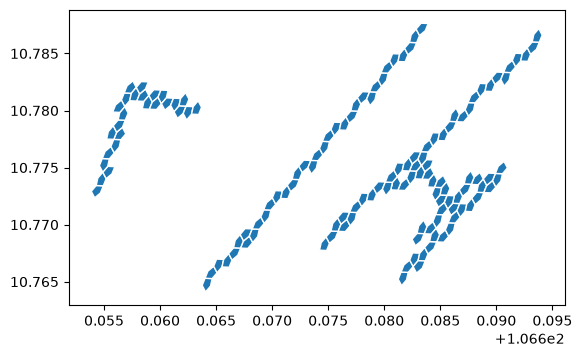

In [2]:
from vgrid.conversion.vector2dggs.vector2a5 import vector2a5

file_path = ("https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polyline.geojson")
options = {"segments": 'auto'}
resolution= 16
polyline_to_a5 = vector2a5(file_path, resolution=resolution, 
                        include_properties=True, output_format="gpd", verbose=True, options=options)
# Visualize vector_to_a5
polyline_to_a5.plot(edgecolor="white")

#### (Multi)Polygon to A5

Processing features: 100%|██████████| 4/4 [00:00<00:00,  6.25it/s]


<Axes: >

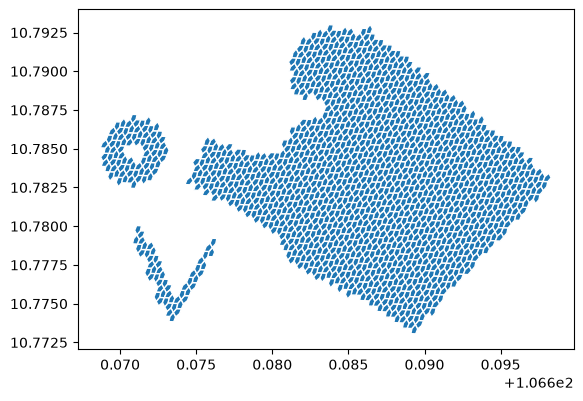

In [2]:
from vgrid.conversion.vector2dggs.vector2a5 import vector2a5

file_path = ("https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon.geojson")
options = {"segments": 'auto'}
resolution= 17
vector_to_a5 = vector2a5(file_path, resolution=resolution, compact = False, depth=-1, predicate = "intersects",
                        include_properties=True, output_format="gpd", verbose=True, options=options)
# Visualize vector_to_a5
vector_to_a5.plot(edgecolor="white")

### A5 Compact

<Axes: >

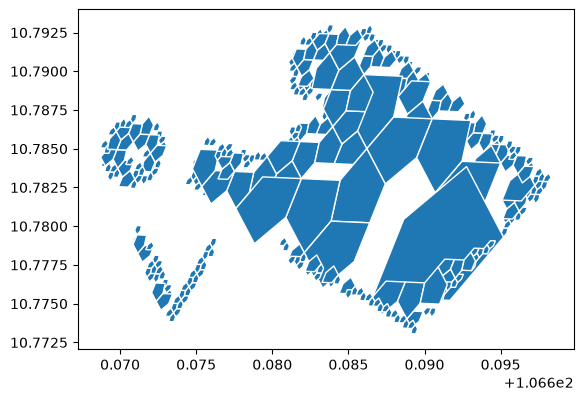

In [4]:
from vgrid.conversion.dggscompact.a5compact import a5compact
options = {"segments": 'auto'}
a5_compacted = a5compact(vector_to_a5, a5_hex="a5", 
                        depth=-1, # -1: full compact
                        output_format="gpd", options=options, verbose=True)
a5_compacted.plot(edgecolor="white")


### A5 Expand

<Axes: >

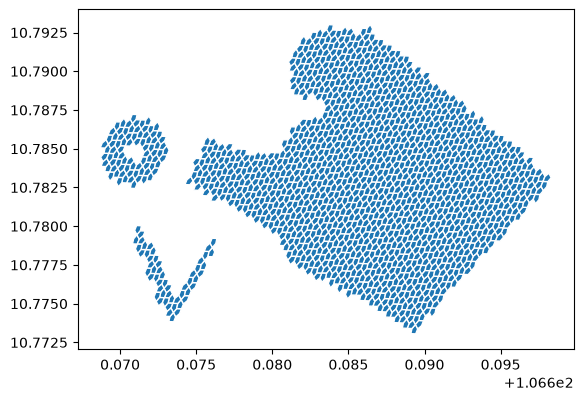

In [7]:
from vgrid.conversion.dggscompact.a5compact import a5expand

a5_expanded = a5expand(a5_compacted, 
                        resolution=17, # choose either resolution or depth
                     #   depth=1, # 
                       output_format="gpd", verbose=True)
a5_expanded.plot(edgecolor="white")

### A5 Binning

In [ ]:
from vgrid.binning.a5bin import a5bin
file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
agg = "max"
numeric_col="median_house_value"

options = {"segments": 'auto'}

a5_bin = a5bin(file_path, 
                resolution=8, 
                agg=agg, 
                numeric_col=numeric_col,
                # category_col="category",
                output_format="gpd", verbose=True,
                options=options)

a5_bin.plot(
    column= f"{numeric_col}_{agg}",        # numeric column to base the colors on
    cmap='Spectral_r',        # color scheme (matplotlib colormap)
    legend=True,  
    linewidth=0.2          # boundary width (optional)
)

### A5 Resampling

In [ ]:
from vgrid.conversion.dggsresample import dggsresample
a5_resample = dggsresample(
    source_dggs=a5_bin,
    dggs_from="a5",
    dggs_to="h3",
    method = "nearest", # area_weighted, nearest
    dggs_col="a5",
    resample_col=f"{numeric_col}_{agg}",  # column on h3_bin with numbers
    fix_antimeridian=None,
    split_antimeridian=False,
    verbose=True,
)
a5_resample.plot(
    column=f"{numeric_col}_{agg}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to A5

#### Download and open raster

In [ ]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, 'r')
print(src.meta)
show(src)

#### Convert raster to A5

In [ ]:
# %pip install folium

In [ ]:
from vgrid.conversion.raster2dggs.raster2a5 import raster2a5
options = {"segments": 'auto'}

raster_to_a5 =  raster2a5(raster_file, 
                        method = 'binning', # binning, nearest
                        stats="mean",resolution = 23, output_format="gpd", verbose=True, options=options)
# Visualize raster_to_a5
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

a5_layer = folium.GeoJson(
    raster_to_a5,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 0.5,
    },
    popup=folium.GeoJsonPopup(
        fields=["a5", "resolution", "band_1", "band_2", "band_3", "cell_area"],
        aliases=["A5 Hex", "Resolution", "Band 1", "Band 2", "Band 3", "Area (m²)"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(a5_layer.get_bounds())

# Display the map
m

### A5 Generator

In [ ]:
from vgrid.generator.a5grid import a5grid
# options = {"segments": 100}
options = {"segments": 'auto'}
resolution = 2
# a5_grid = a5grid(resolution=resolution,output_format="gpd", options=options, split_antimeridian=False)
a5_grid = a5grid(resolution=16,
                bbox=[106.699007, 10.762811, 106.717674, 10.778649],
                compact=True, output_format="gpd", verbose=True) 
# a5_grid.to_crs('proj=moll').plot(edgecolor='white')
# a5_grid = a5grid(resolution=resolution,bbox=None,compact=True, output_format="gpd") 
a5_grid.plot(edgecolor='white')

### A5 Inspect

In [ ]:
from vgrid.stats.a5stats import a5inspect
resolution = 6
options = {"segments": 100}
a5_inspect = a5inspect(resolution, options, split_antimeridian=False, verbose=True)
a5_inspect.head()
# a5_inspect.to_crs('proj=moll').plot()

### A5 Normalized Area Histogram

In [ ]:
from vgrid.stats.a5stats import a5_norm_area_hist
a5_norm_area_hist(a5_inspect)

### Distribution of A5 Area Distortions

In [ ]:
from vgrid.stats.a5stats import a5_norm_area
a5_norm_area(a5_inspect)

### A5 IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is (0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


In [ ]:
from vgrid.stats.a5stats import a5_compactness_ipq_hist
a5_compactness_ipq_hist(a5_inspect)

### Distribution of A5 IPQ Compactness

In [ ]:
from vgrid.stats.a5stats import a5_compactness_ipq
a5_compactness_ipq(a5_inspect)

### A5 Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is (0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

In [ ]:
from vgrid.stats.a5stats import a5_compactness_cvh_hist
a5_compactness_cvh_hist(a5_inspect)

### Distribution of A5 Convex hull Compactness

In [ ]:
from vgrid.stats.a5stats import a5_compactness_cvh
a5_compactness_cvh(a5_inspect)

### A5 Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [ ]:
from vgrid.stats.a5stats import a5stats
a5stats('m')